# Exploratory Data Analysis for Energy Efficiency Prediction
This notebook performs leakage-aware exploratory data analysis for the heating-load prediction project.
The test set is kept untouched for final model evaluation.

In [142]:
# IMPORT LIBRARIES 
from __future__ import annotations

import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.model_selection import train_test_split

# Project path
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.feature_engineering import BASE_FEATURES, ENGINEERED_FEATURES
from src.utils import load_data

# Output directory
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Reproducibility
RANDOM_STATE = 42
TEST_SIZE = 0.20

# Visual style
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

print(f"Project root: {PROJECT_ROOT}")
print(f"Figures will be saved to: {FIGURES_DIR}")


Project root: /Users/sari/PythonProjects/energy-efficiency-prediction
Figures will be saved to: /Users/sari/PythonProjects/energy-efficiency-prediction/outputs/figures


In [143]:
# LOAD DATA
df = load_data().copy()

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

display(df.head())

Dataset shape: (768, 10)
Columns: ['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area', 'Overall_Height', 'Orientation', 'Glazing_Area', 'Glazing_Area_Distribution', 'Heating_Load', 'Cooling_Load']


,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


To reduce leakage risk, the dataset is split before performing detailed exploratory analysis.

- The **training set** is used for distributions, correlations, outlier analysis, and feature relationships.
- The **test set** remains untouched until final model evaluation.

In [144]:
# SPLIT DATA BEFORE DETAILED EDA
TARGET = "Heating_Load"
SECOND_TARGET = "Cooling_Load"

if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' was not found.")

# Keep all original design columns temporarily so EDA can show why
# Surface_Area was removed. Production modelling uses BASE_FEATURES.
X_raw = df.drop(columns=[TARGET, SECOND_TARGET], errors="ignore")
y = pd.to_numeric(df[TARGET], errors="raise")

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

raw_train_df = X_train_raw.copy()
raw_train_df[TARGET] = y_train

# Production-compatible feature frames: 7 raw inputs, no Surface_Area.
X_train = X_train_raw[BASE_FEATURES].copy()
X_test = X_test_raw[BASE_FEATURES].copy()

train_df = X_train.copy()
train_df[TARGET] = y_train

test_df = X_test.copy()
test_df[TARGET] = y_test

print(f"Raw training shape for EDA: {raw_train_df.shape}")
print(f"Production training shape: {train_df.shape}")
print(f"Production test shape: {test_df.shape}")
print(f"Production raw inputs: {BASE_FEATURES}")
print("Detailed EDA uses training data only.")


Raw training shape for EDA: (614, 9)
Production training shape: (614, 8)
Production test shape: (154, 8)
Production raw inputs: ['Relative_Compactness', 'Wall_Area', 'Roof_Area', 'Overall_Height', 'Orientation', 'Glazing_Area', 'Glazing_Area_Distribution']
Detailed EDA uses training data only.


In [145]:
# DATA OVERVIEW
print("\n--- Raw Training Data Info ---")
raw_train_df.info()

print("\n--- Production Feature Statistics ---")
display(train_df.describe().T)

missing_values = raw_train_df.isnull().sum()
duplicate_count = raw_train_df.duplicated().sum()

print("\n--- Missing Values ---")
display(missing_values.to_frame("Missing Values"))

print(f"\nDuplicate rows in raw training data: {duplicate_count}")



--- Raw Training Data Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 60 to 102
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Relative_Compactness       614 non-null    float64
 1   Surface_Area               614 non-null    float64
 2   Wall_Area                  614 non-null    float64
 3   Roof_Area                  614 non-null    float64
 4   Overall_Height             614 non-null    float64
 5   Orientation                614 non-null    int64  
 6   Glazing_Area               614 non-null    float64
 7   Glazing_Area_Distribution  614 non-null    int64  
 8   Heating_Load               614 non-null    float64
dtypes: float64(7), int64(2)
memory usage: 48.0 KB

--- Production Feature Statistics ---


,count,mean,std,min,25%,50%,75%,max
Relative_Compactness,614.0,0.761678,0.105424,0.62,0.6600,0.74,0.820,0.98
Wall_Area,614.0,318.819218,43.335953,245.00,294.0000,318.50,343.000,416.50
Roof_Area,614.0,177.505293,44.960238,110.25,147.0000,220.50,220.500,220.50
Overall_Height,614.0,5.221498,1.751195,3.50,3.5000,3.50,7.000,7.00
Orientation,614.0,3.511401,1.108635,2.00,3.0000,4.00,4.000,5.00
Glazing_Area,614.0,0.235423,0.134152,0.00,0.1000,0.25,0.400,0.40
Glazing_Area_Distribution,614.0,2.799674,1.551908,0.00,1.2500,3.00,4.000,5.00
Heating_Load,614.0,22.155033,10.054280,6.01,12.9775,18.25,31.545,43.10



--- Missing Values ---


,Missing Values
Relative_Compactness,0
Surface_Area,0
Wall_Area,0
Roof_Area,0
Overall_Height,0
Orientation,0
Glazing_Area,0
Glazing_Area_Distribution,0
Heating_Load,0



Duplicate rows in raw training data: 0


In [146]:
# PRODUCTION FEATURE GROUPS
categorical_cols = [
    "Orientation",
    "Glazing_Area_Distribution",
]
numerical_cols = [
    column
    for column in BASE_FEATURES
    if column not in categorical_cols
]

print("Numerical production features:", numerical_cols)
print("Categorical production features:", categorical_cols)
print("Engineered features:", ENGINEERED_FEATURES)

print(
    "\nCompatibility note: actual scaling, encoding and imputation are handled "
    "inside src/preprocessing.py and src/train.py. EDA does not fit deployment "
    "preprocessors."
)


Numerical production features: ['Relative_Compactness', 'Wall_Area', 'Roof_Area', 'Overall_Height', 'Glazing_Area']
Categorical production features: ['Orientation', 'Glazing_Area_Distribution']
Engineered features: ['Compactness_Height']

Compatibility note: actual scaling, encoding and imputation are handled inside src/preprocessing.py and src/train.py. EDA does not fit deployment preprocessors.


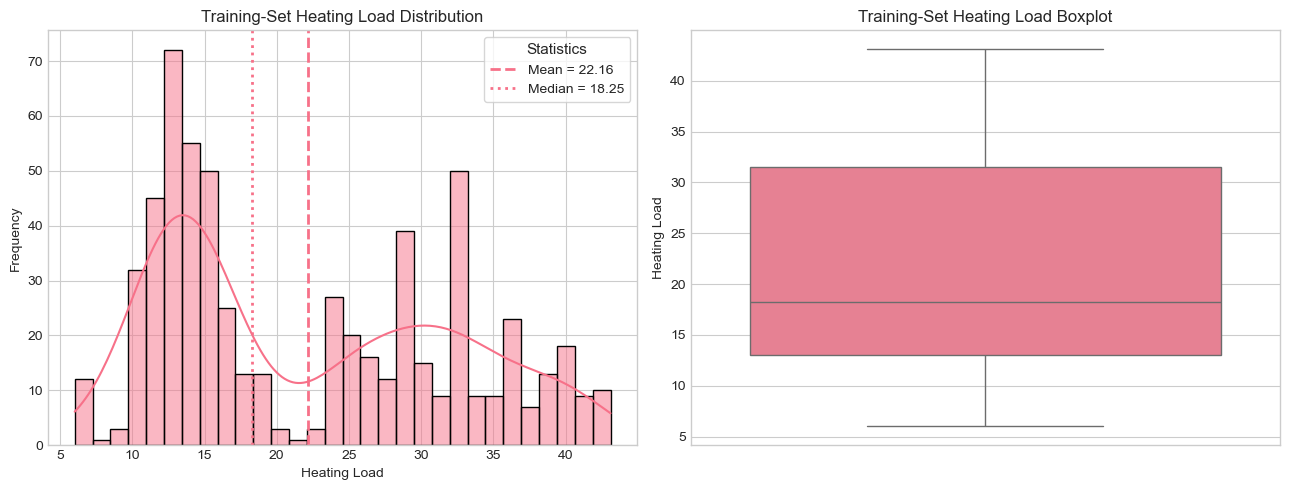

,Statistic,Value
0,Mean,22.1550
1,Median,18.2500
2,Standard Deviation,10.0543
3,Minimum,6.0100
4,Maximum,43.1000
5,Skewness,0.3987


In [147]:
# TARGET VARIABLE ANALYSIS

target_mean = train_df[TARGET].mean()
target_median = train_df[TARGET].median()
target_std = train_df[TARGET].std()
target_min = train_df[TARGET].min()
target_max = train_df[TARGET].max()
target_skew = train_df[TARGET].skew()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(
    train_df[TARGET],
    bins=30,
    kde=True,
    ax=axes[0],
)

axes[0].axvline(
    target_mean,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {target_mean:.2f}"
)

axes[0].axvline(
    target_median,
    linestyle=":",
    linewidth=2,
    label=f"Median = {target_median:.2f}"
)

axes[0].set_title("Training-Set Heating Load Distribution")
axes[0].set_xlabel("Heating Load")
axes[0].set_ylabel("Frequency")

# Legend
axes[0].legend(
    title="Statistics",
    loc="upper right",
    frameon=True,
    fancybox=True,
    shadow=False,
    fontsize=10,
    title_fontsize=11
)

sns.boxplot(
    y=train_df[TARGET],
    ax=axes[1]
)

axes[1].set_title("Training-Set Heating Load Boxplot")
axes[1].set_ylabel("Heating Load")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "eda_heating_load_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

target_summary = pd.DataFrame(
    {
        "Statistic": [
            "Mean",
            "Median",
            "Standard Deviation",
            "Minimum",
            "Maximum",
            "Skewness",
        ],
        "Value": [
            target_mean,
            target_median,
            target_std,
            target_min,
            target_max,
            target_skew,
        ],
    }
)

display(target_summary.round(4))

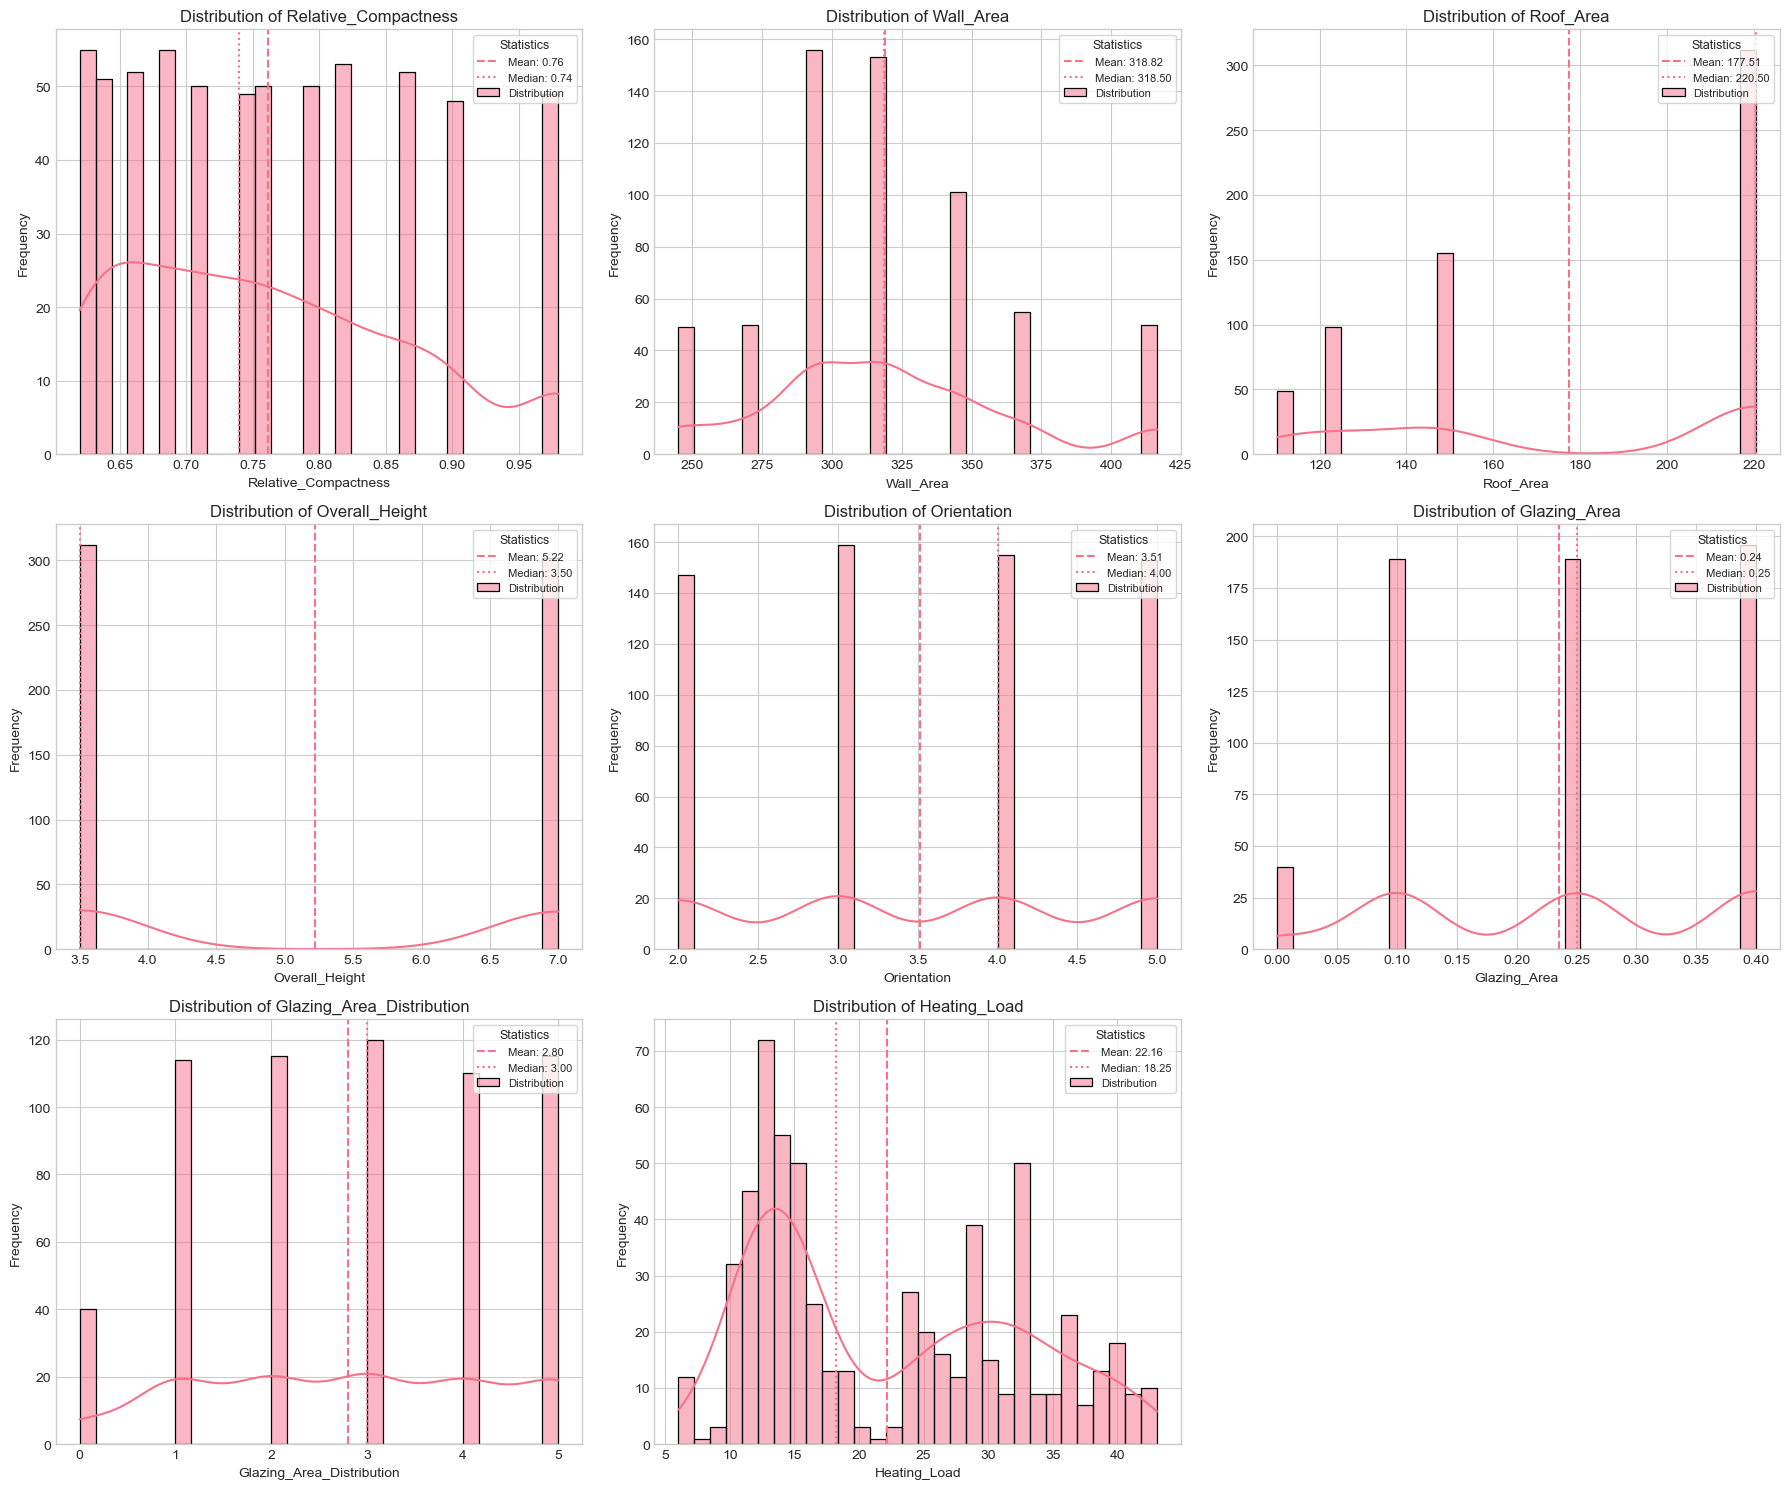

In [148]:
# NUMERICAL FEATURE DISTRIBUTIONS WITH STATISTICS

numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()

n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = np.asarray(axes).reshape(-1)

for index, column in enumerate(numeric_cols):
    sns.histplot(
        train_df[column],
        kde=True,
        bins=30,
        ax=axes[index],
        label="Distribution",
    )

    mean_val = train_df[column].mean()
    median_val = train_df[column].median()

    axes[index].axvline(
        mean_val,
        linestyle="--",
        linewidth=1.5,
        label=f"Mean: {mean_val:.2f}",
    )

    axes[index].axvline(
        median_val,
        linestyle=":",
        linewidth=1.5,
        label=f"Median: {median_val:.2f}",
    )

    axes[index].set_title(f"Distribution of {column}")
    axes[index].set_xlabel(column)
    axes[index].set_ylabel("Frequency")

    # Legend
    axes[index].legend(
        title="Statistics",
        loc="upper right",
        frameon=True,
        fancybox=True,
        shadow=False,
        fontsize=8,
        title_fontsize=9,
    )

for index in range(len(numeric_cols), len(axes)):
    axes[index].set_visible(False)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "eda_feature_distributions_with_stats.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [149]:
# SKEWNESS ANALYSIS 
skewness = (
    train_df[numeric_cols]
    .skew()
    .sort_values(key=np.abs, ascending=False)
    .to_frame("Skewness")
)

skewness["Absolute Skewness"] = skewness["Skewness"].abs()
skewness["Interpretation"] = pd.cut(
    skewness["Absolute Skewness"],
    bins=[-np.inf, 0.5, 1.0, np.inf],
    labels=["Approximately symmetric", "Moderately skewed", "Highly skewed"],
)

display(skewness.round(4))

,Skewness,Absolute Skewness,Interpretation
Wall_Area,0.5285,0.5285,Moderately skewed
Relative_Compactness,0.5132,0.5132,Moderately skewed
Heating_Load,0.3987,0.3987,Approximately symmetric
Roof_Area,-0.1948,0.1948,Approximately symmetric
Glazing_Area_Distribution,-0.0809,0.0809,Approximately symmetric
Glazing_Area,-0.0793,0.0793,Approximately symmetric
Overall_Height,0.0327,0.0327,Approximately symmetric
Orientation,-0.0072,0.0072,Approximately symmetric


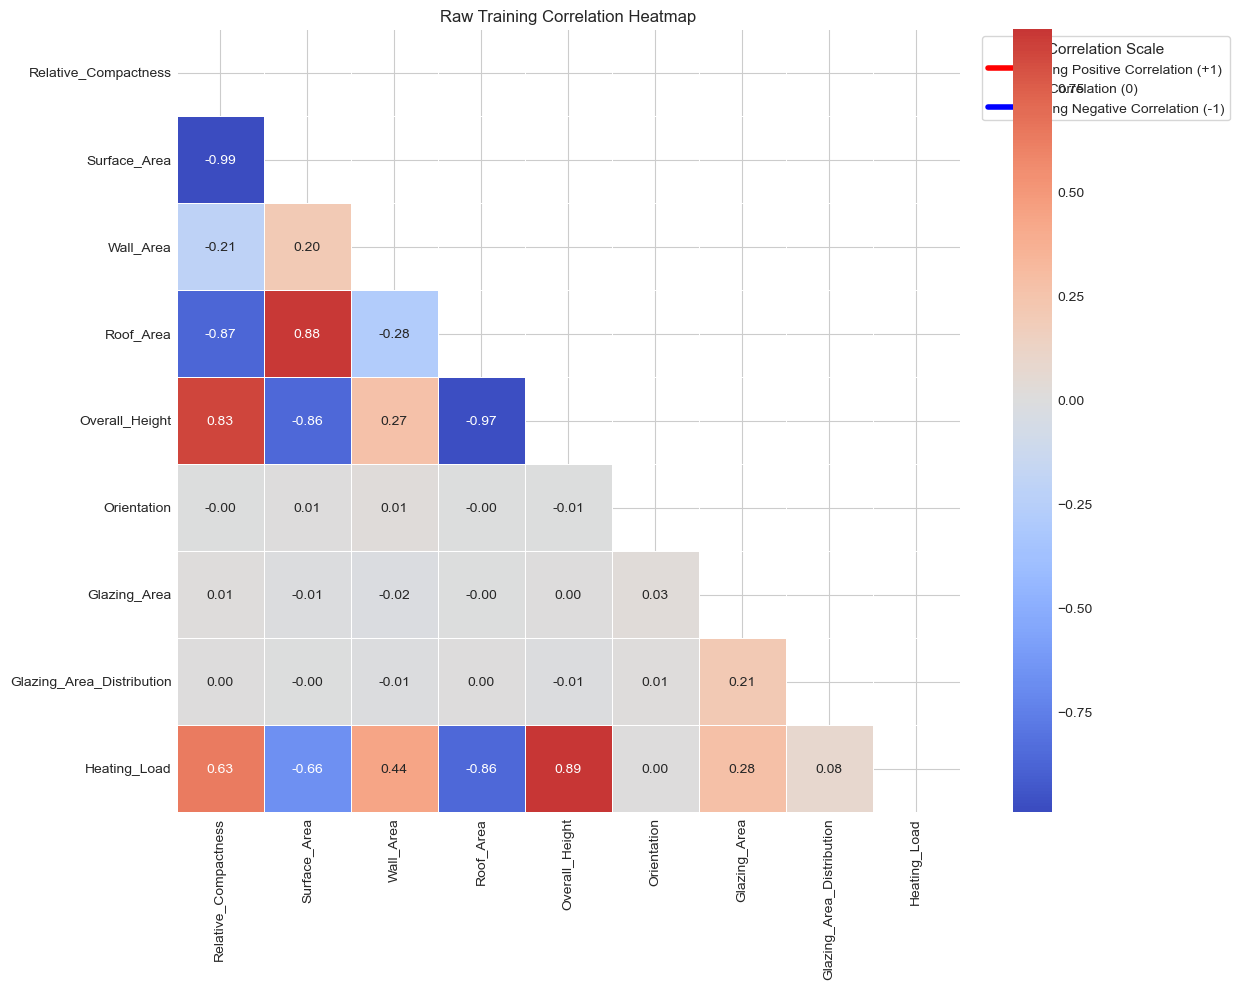

,Feature,Correlation with Heating Load,Absolute Correlation
0,Overall_Height,0.8892,0.8892
1,Roof_Area,-0.8633,0.8633
2,Surface_Area,-0.6647,0.6647
3,Relative_Compactness,0.6293,0.6293
4,Wall_Area,0.4391,0.4391
5,Glazing_Area,0.2762,0.2762
6,Glazing_Area_Distribution,0.0802,0.0802
7,Orientation,0.0018,0.0018


Surface_Area is retained here only to document multicollinearity. It is excluded from BASE_FEATURES used by training and prediction.


In [150]:
# RAW CORRELATION ANALYSIS — INCLUDES SURFACE AREA FOR DIAGNOSIS

raw_numeric_cols = raw_train_df.select_dtypes(include=[np.number]).columns.tolist()
raw_corr_matrix = raw_train_df[raw_numeric_cols].corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(raw_corr_matrix, dtype=bool))

sns.heatmap(
    raw_corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
)

# Legend
from matplotlib.lines import Line2D

legend_elements = [
    Line2D(
        [0],
        [0],
        color="red",
        lw=4,
        label="Strong Positive Correlation (+1)"
    ),
    Line2D(
        [0],
        [0],
        color="white",
        lw=4,
        label="No Correlation (0)"
    ),
    Line2D(
        [0],
        [0],
        color="blue",
        lw=4,
        label="Strong Negative Correlation (-1)"
    ),
]

plt.legend(
    handles=legend_elements,
    title="Correlation Scale",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=True,
    fontsize=10,
    title_fontsize=11,
)

plt.title("Raw Training Correlation Heatmap")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "eda_raw_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

raw_target_corr = (
    raw_corr_matrix[TARGET]
    .drop(TARGET)
    .sort_values(key=np.abs, ascending=False)
)

display(
    pd.DataFrame(
        {
            "Feature": raw_target_corr.index,
            "Correlation with Heating Load": raw_target_corr.values,
            "Absolute Correlation": raw_target_corr.abs().values,
        }
    ).round(4)
)

print(
    "Surface_Area is retained here only to document multicollinearity. "
    "It is excluded from BASE_FEATURES used by training and prediction."
)

In [151]:
# PRODUCTION FEATURE SET AFTER MULTICOLLINEARITY DECISION
assert "Surface_Area" not in BASE_FEATURES
assert "Surface_Area" not in X_train.columns
assert list(X_train.columns) == BASE_FEATURES

unique_counts = pd.DataFrame(
    {
        "Feature": X_train.columns,
        "Unique Values": [
            X_train[column].nunique()
            for column in X_train.columns
        ],
    }
).sort_values("Unique Values")

unique_counts["Possible Type"] = np.where(
    unique_counts["Unique Values"] <= 10,
    "Discrete / categorical-like",
    "Continuous",
)

display(unique_counts)


,Feature,Unique Values,Possible Type
3,Overall_Height,2,Discrete / categorical-like
2,Roof_Area,4,Discrete / categorical-like
4,Orientation,4,Discrete / categorical-like
5,Glazing_Area,4,Discrete / categorical-like
6,Glazing_Area_Distribution,6,Discrete / categorical-like
1,Wall_Area,7,Discrete / categorical-like
0,Relative_Compactness,12,Continuous


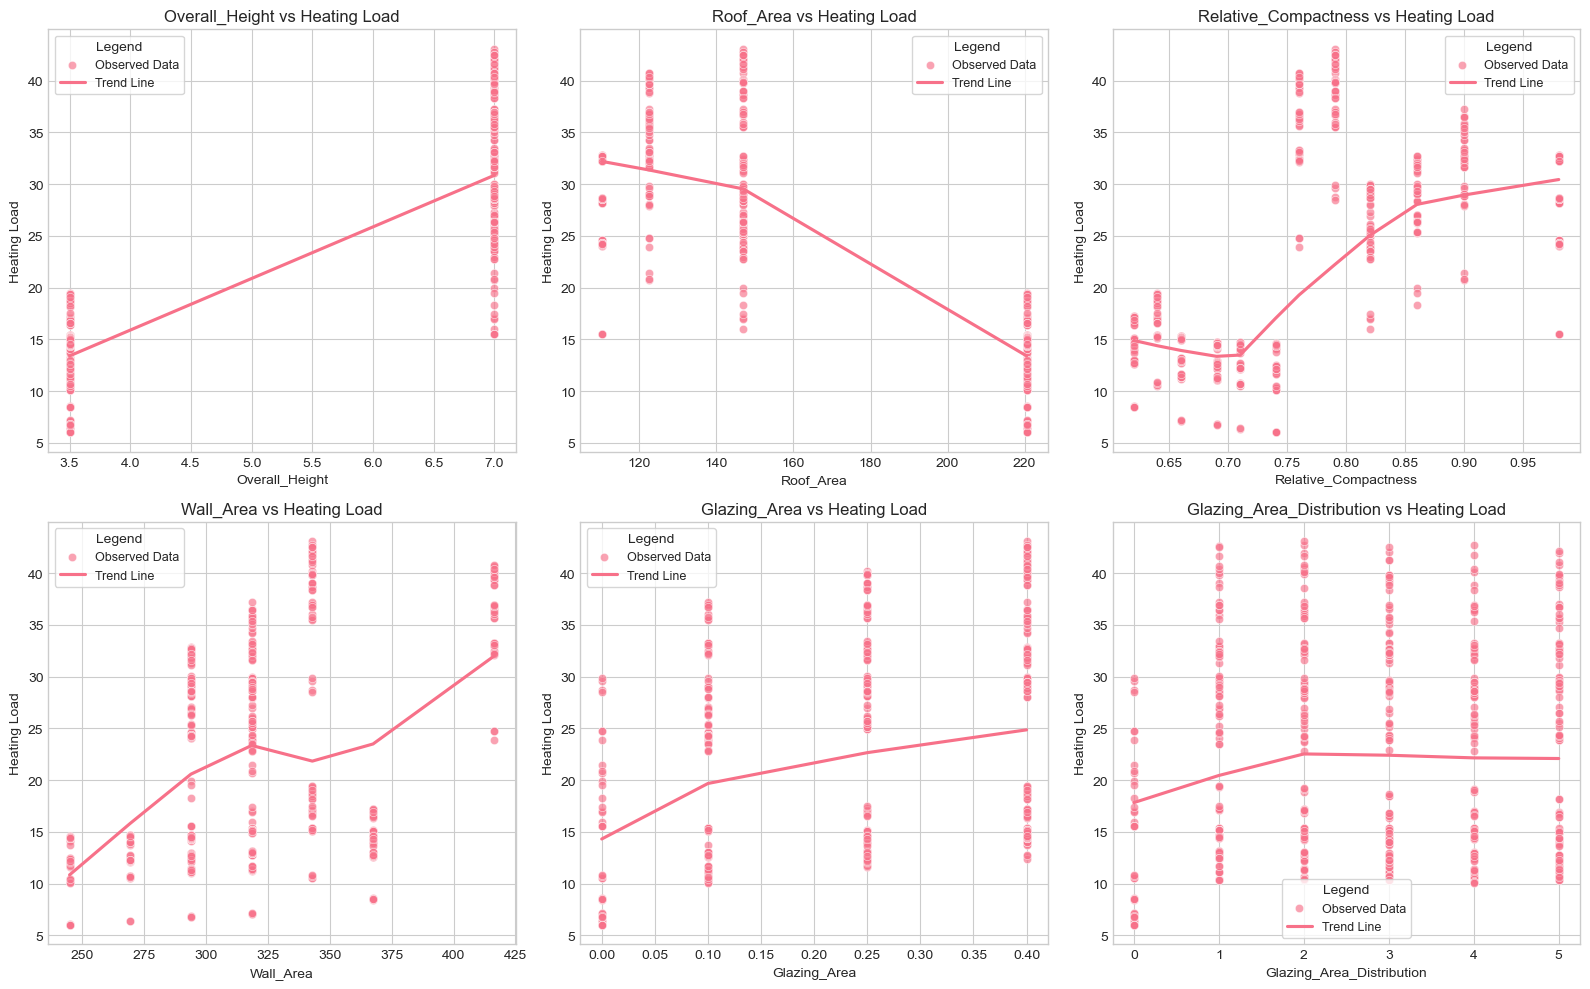

,Feature,Correlation with Heating Load,Absolute Correlation
0,Overall_Height,0.8892,0.8892
1,Roof_Area,-0.8633,0.8633
2,Relative_Compactness,0.6293,0.6293
3,Wall_Area,0.4391,0.4391
4,Glazing_Area,0.2762,0.2762
5,Glazing_Area_Distribution,0.0802,0.0802
6,Orientation,0.0018,0.0018


In [152]:
# PRODUCTION CORRELATIONS AND FEATURE RELATIONSHIPS

numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = train_df[numeric_cols].corr()

target_corr = (
    corr_matrix[TARGET]
    .drop(TARGET)
    .sort_values(key=np.abs, ascending=False)
)

correlation_table = pd.DataFrame(
    {
        "Feature": target_corr.index,
        "Correlation with Heating Load": target_corr.values,
        "Absolute Correlation": target_corr.abs().values,
    }
)

top_features = target_corr.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = np.asarray(axes).reshape(-1)

for index, feature in enumerate(top_features):
    sns.scatterplot(
        data=train_df,
        x=feature,
        y=TARGET,
        alpha=0.65,
        ax=axes[index],
        label="Observed Data",
    )

    sns.regplot(
        data=train_df,
        x=feature,
        y=TARGET,
        scatter=False,
        lowess=True,
        ax=axes[index],
        label="Trend Line",
    )

    axes[index].set_title(f"{feature} vs Heating Load")
    axes[index].set_xlabel(feature)
    axes[index].set_ylabel("Heating Load")

    # Legend
    axes[index].legend(
        title="Legend",
        loc="best",
        frameon=True,
        fancybox=True,
        shadow=False,
        fontsize=9,
        title_fontsize=10,
    )

for index in range(len(top_features), len(axes)):
    axes[index].set_visible(False)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "eda_top_feature_relationships.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

display(correlation_table.round(4))

,Feature,Outlier Count,Outlier Percentage
0,Relative_Compactness,0,0.0
1,Wall_Area,0,0.0
2,Roof_Area,0,0.0
3,Overall_Height,0,0.0
4,Orientation,0,0.0
5,Glazing_Area,0,0.0
6,Glazing_Area_Distribution,0,0.0
7,Heating_Load,0,0.0


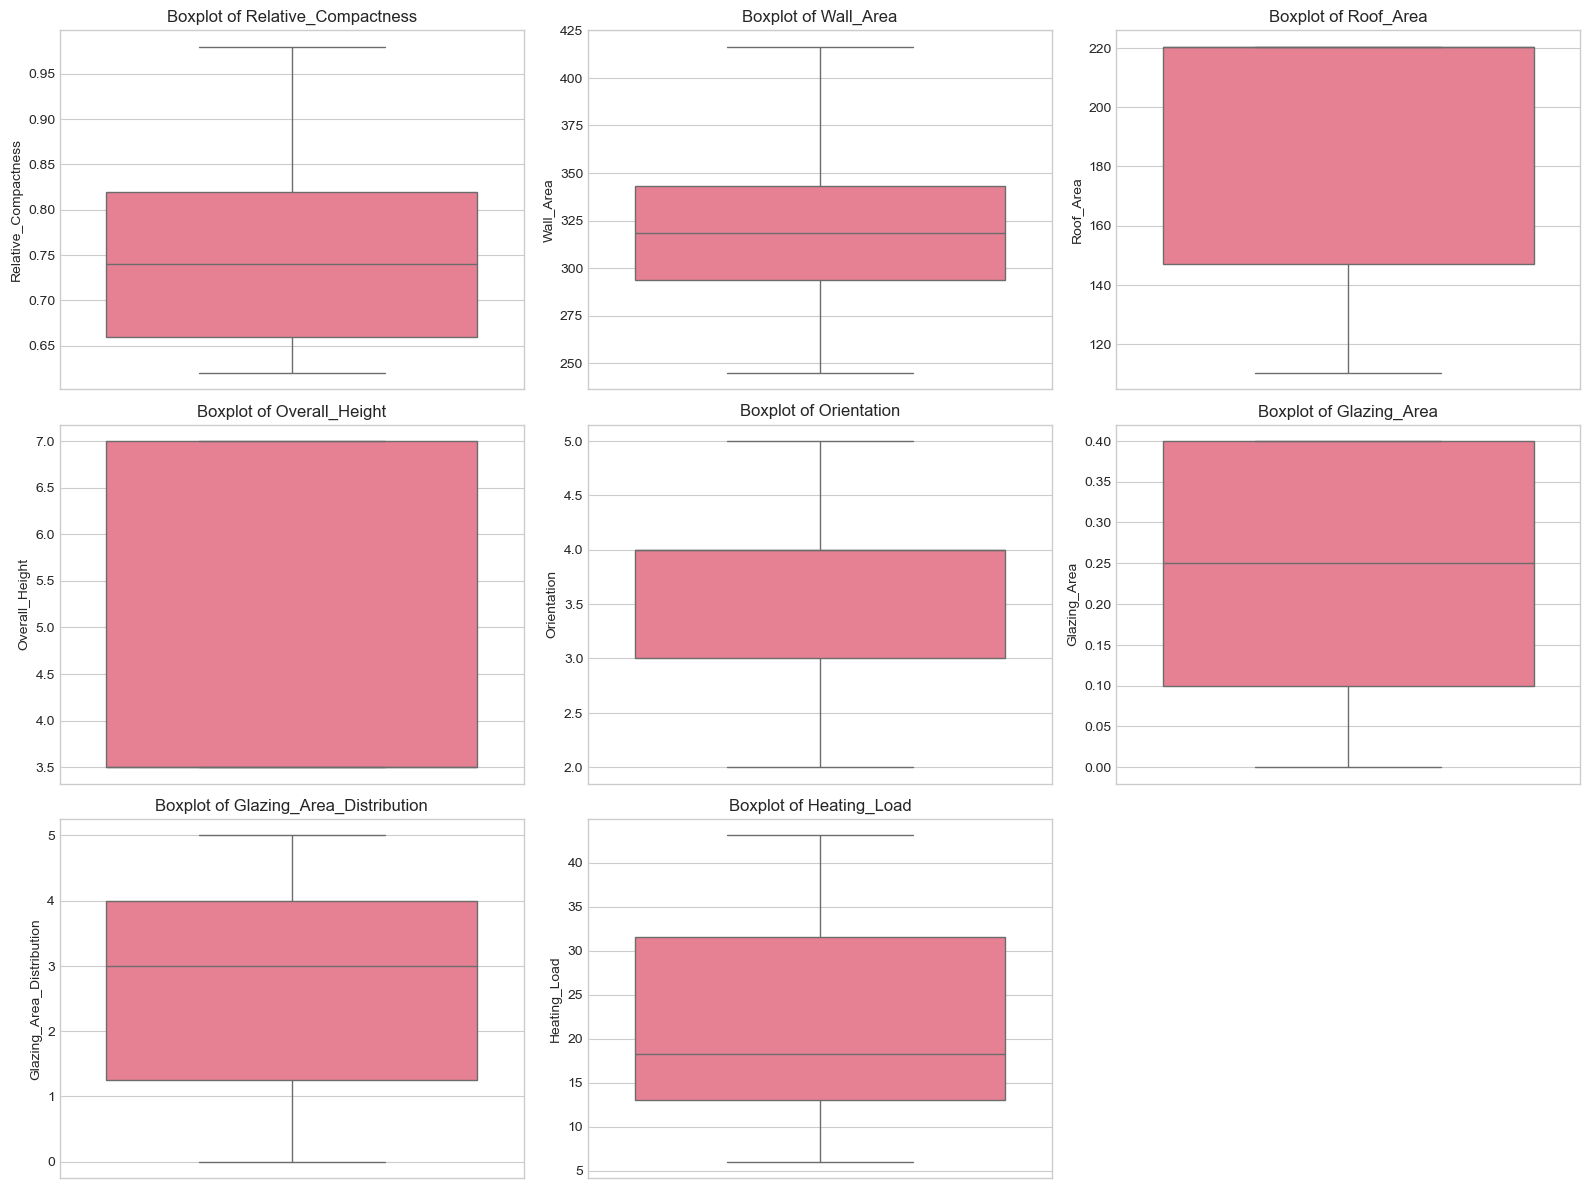

In [153]:
#OUTLIER DETECTION
def detect_outliers_iqr(
    dataframe: pd.DataFrame,
    column: str,
    threshold: float = 1.5,
) -> pd.DataFrame:
    q1 = dataframe[column].quantile(0.25)
    q3 = dataframe[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - threshold * iqr
    upper_bound = q3 + threshold * iqr

    return dataframe[
        (dataframe[column] < lower_bound)
        | (dataframe[column] > upper_bound)
    ]

outlier_rows = []

for column in numeric_cols:
    detected = detect_outliers_iqr(train_df, column)

    outlier_rows.append(
        {
            "Feature": column,
            "Outlier Count": len(detected),
            "Outlier Percentage": len(detected) / len(train_df) * 100,
        }
    )

outlier_df = pd.DataFrame(outlier_rows).sort_values(
    "Outlier Count",
    ascending=False,
)

display(outlier_df.round(3))

n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for index, column in enumerate(numeric_cols):
    sns.boxplot(y=train_df[column], ax=axes[index])
    axes[index].set_title(f"Boxplot of {column}")

for index in range(len(numeric_cols), len(axes)):
    axes[index].set_visible(False)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "eda_feature_boxplots.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [154]:
# TOP PRODUCTION CORRELATIONS
print("Top production features correlated with Heating_Load:")
display(
    correlation_table.head(7).style.background_gradient(
        cmap="coolwarm",
        subset=["Correlation with Heating Load"],
    )
)


Top production features correlated with Heating_Load:


,Feature,Correlation with Heating Load,Absolute Correlation
0,Overall_Height,0.889154,0.889154
1,Roof_Area,-0.863294,0.863294
2,Relative_Compactness,0.629314,0.629314
3,Wall_Area,0.439092,0.439092
4,Glazing_Area,0.276184,0.276184
5,Glazing_Area_Distribution,0.080206,0.080206
6,Orientation,0.001772,0.001772


Production correlation matrix:


,Relative_Compactness,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load
Relative_Compactness,1.0000,-0.2119,-0.8704,0.8311,-0.0034,0.0096,0.0012,0.6293
Wall_Area,-0.2119,1.0000,-0.2812,0.2674,0.0149,-0.0198,-0.0121,0.4391
Roof_Area,-0.8704,-0.2812,1.0000,-0.9728,-0.0020,-0.0032,0.0041,-0.8633
Overall_Height,0.8311,0.2674,-0.9728,1.0000,-0.0072,0.0037,-0.0074,0.8892
Orientation,-0.0034,0.0149,-0.0020,-0.0072,1.0000,0.0294,0.0103,0.0018
Glazing_Area,0.0096,-0.0198,-0.0032,0.0037,0.0294,1.0000,0.2069,0.2762
Glazing_Area_Distribution,0.0012,-0.0121,0.0041,-0.0074,0.0103,0.2069,1.0000,0.0802
Heating_Load,0.6293,0.4391,-0.8633,0.8892,0.0018,0.2762,0.0802,1.0000


Heatmap saved to: /Users/sari/PythonProjects/energy-efficiency-prediction/outputs/figures/eda_correlation_heatmap.png


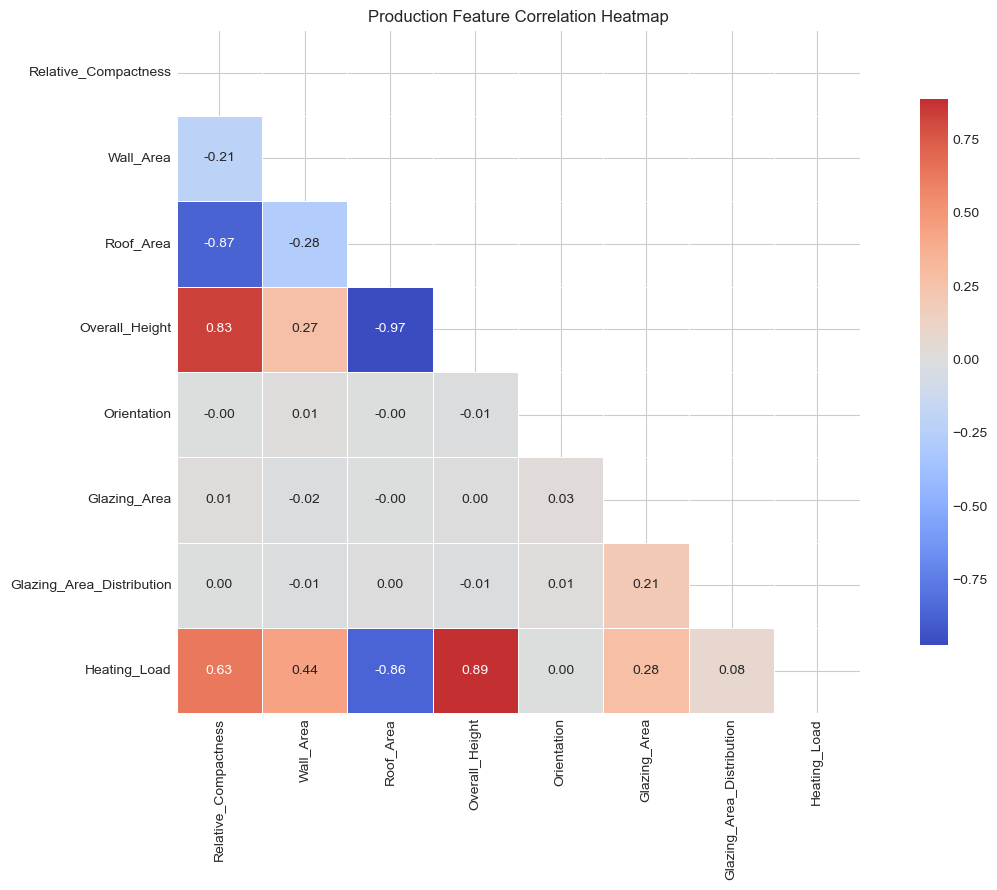

In [155]:
# PRODUCTION CORRELATION MATRIX & HEATMAP
corr_matrix = train_df[numeric_cols].corr()

print("Production correlation matrix:")
display(corr_matrix.round(4))

plt.figure(figsize=(13, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)

plt.title("Production Feature Correlation Heatmap")
plt.tight_layout()

heatmap_path = FIGURES_DIR / "eda_correlation_heatmap.png"
plt.savefig(heatmap_path, dpi=300, bbox_inches="tight")
print(f"Heatmap saved to: {heatmap_path}")
plt.show()


In [156]:
#UNIQUE VALUES AND POSSIBLE CATEGORICAL FEATURES 
unique_counts = pd.DataFrame(
    {
        "Feature": X_train.columns,
        "Unique Values": [X_train[column].nunique() for column in X_train.columns],
    }
).sort_values("Unique Values")

unique_counts["Possible Type"] = np.where(
    unique_counts["Unique Values"] <= 10,
    "Discrete / categorical-like",
    "Continuous",
)

display(unique_counts)

,Feature,Unique Values,Possible Type
3,Overall_Height,2,Discrete / categorical-like
2,Roof_Area,4,Discrete / categorical-like
4,Orientation,4,Discrete / categorical-like
5,Glazing_Area,4,Discrete / categorical-like
6,Glazing_Area_Distribution,6,Discrete / categorical-like
1,Wall_Area,7,Discrete / categorical-like
0,Relative_Compactness,12,Continuous


In [157]:
# CATEGORICAL FEATURE REVIEW
category_summary = pd.DataFrame(
    {
        "Feature": categorical_cols,
        "Categories": [
            sorted(X_train[column].unique().tolist())
            for column in categorical_cols
        ],
        "Unique Count": [
            X_train[column].nunique()
            for column in categorical_cols
        ],
    }
)

display(category_summary)

print(
    "No manual one-hot encoding is performed in this notebook. "
    "Deployment preprocessing handles encoding consistently inside the "
    "training pipeline."
)


,Feature,Categories,Unique Count
0,Orientation,"[2, 3, 4, 5]",4
1,Glazing_Area_Distribution,"[0, 1, 2, 3, 4, 5]",6


No manual one-hot encoding is performed in this notebook. Deployment preprocessing handles encoding consistently inside the training pipeline.


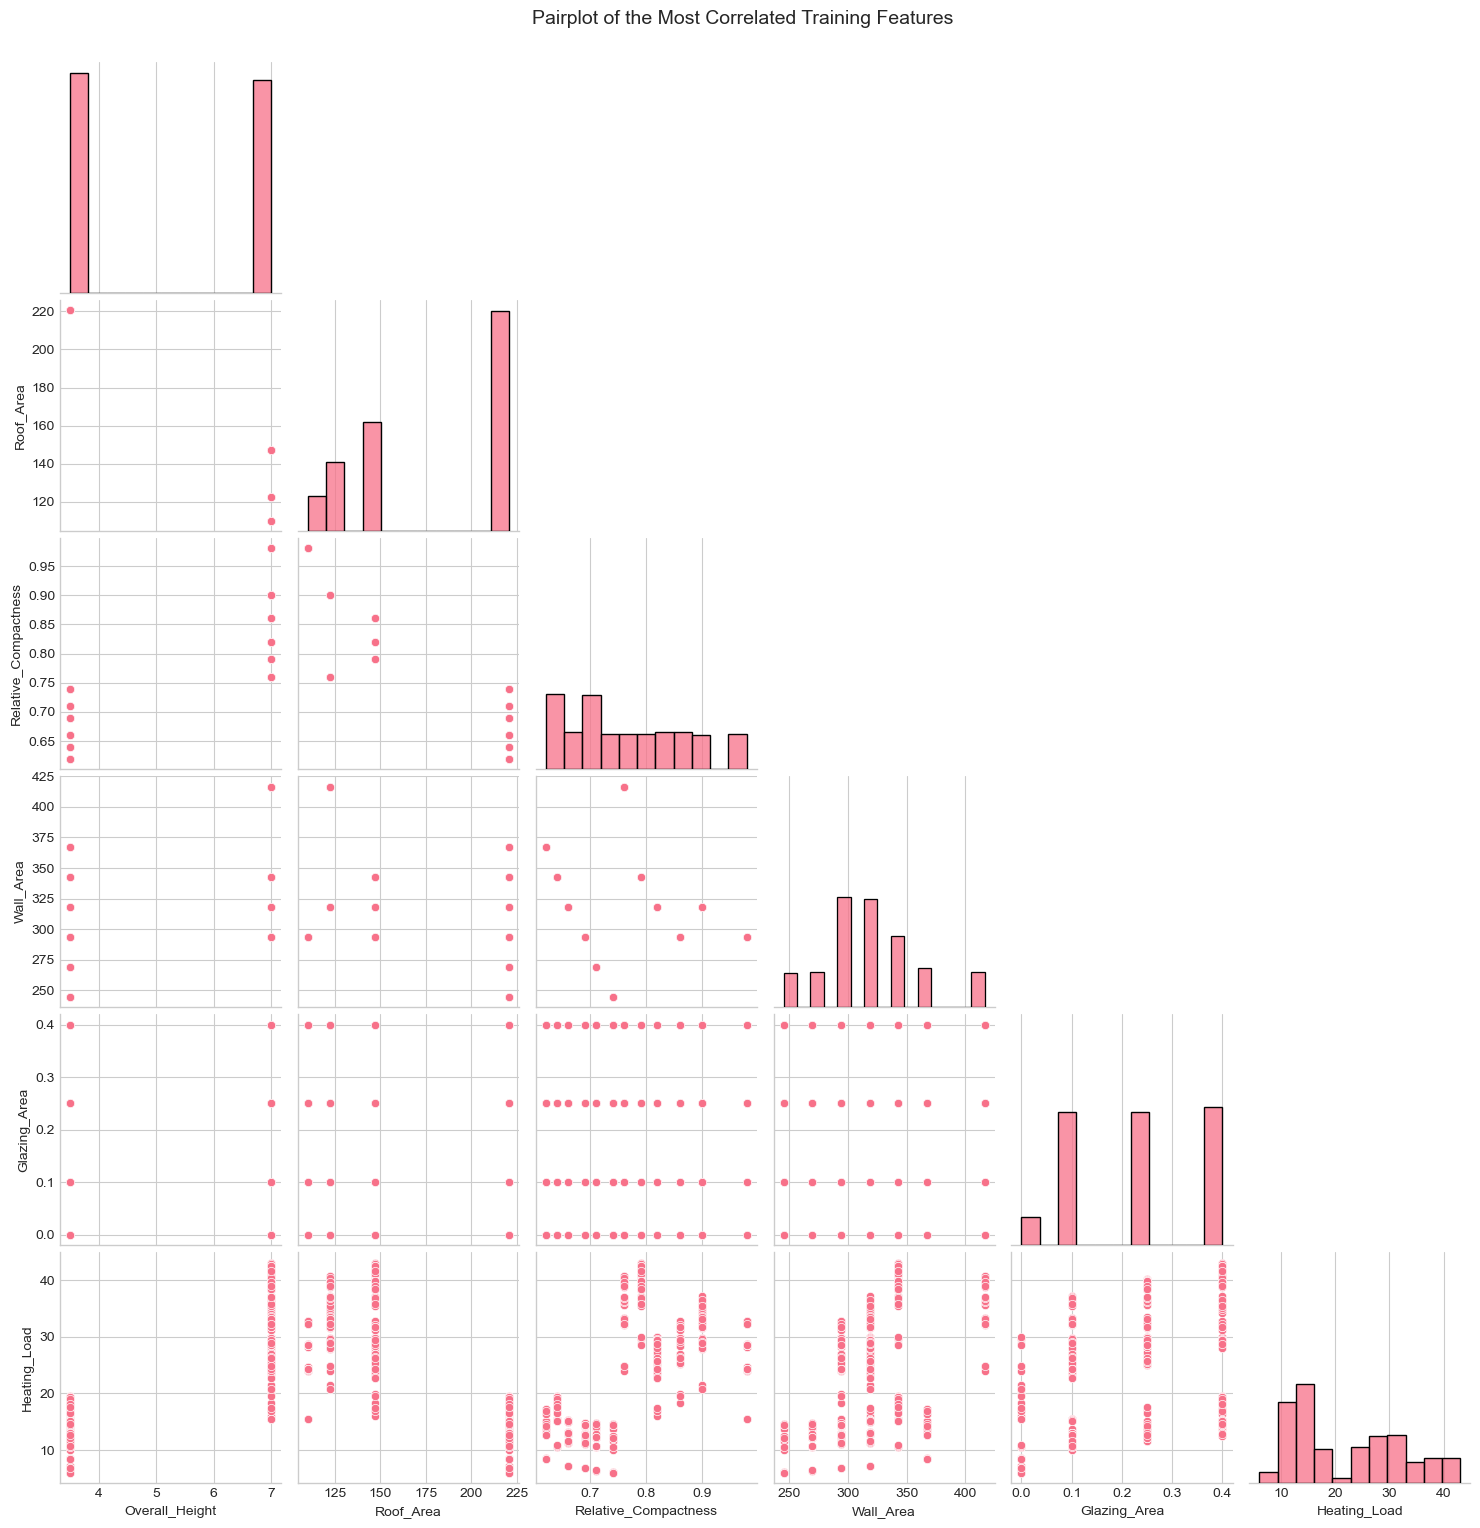

In [158]:
#PAIRPLOT OF KEY FEATURES 
pairplot_features = top_features[:5] + [TARGET]

pairplot = sns.pairplot(
    train_df[pairplot_features],
    diag_kind="hist",
    corner=True,
)

pairplot.fig.suptitle(
    "Pairplot of the Most Correlated Training Features",
    y=1.02,
    fontsize=14,
)

pairplot.savefig(
    FIGURES_DIR / "eda_key_feature_pairplot.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

The following cell creates conclusions using the actual values calculated above.  
No correlation, outlier, or distribution claim is hard-coded.

In [159]:
#DYNAMIC INSIGHTS AND CONCLUSIONS 
strong_positive = target_corr[target_corr >= 0.60]
strong_negative = target_corr[target_corr <= -0.60]
moderate = target_corr[
    (target_corr.abs() >= 0.30)
    & (target_corr.abs() < 0.60)
]

features_with_missing = missing_values[missing_values > 0]
features_with_outliers = outlier_df[outlier_df["Outlier Count"] > 0]
highly_skewed = skewness[skewness["Absolute Skewness"] > 1.0]

if abs(target_skew) < 0.5:
    target_shape = "approximately symmetric"
elif abs(target_skew) < 1.0:
    target_shape = "moderately skewed"
else:
    target_shape = "highly skewed"

insight_lines = [
    "# EDA Findings Based on the Actual Training Data",
    "",
    "## Data quality",
    "",
    f"- Training observations: **{len(train_df):,}**.",
    f"- Test observations kept untouched: **{len(test_df):,}**.",
    f"- Missing values: **{int(missing_values.sum())}** in total.",
    f"- Duplicate training rows: **{duplicate_count}**.",
    "",
    "## Target distribution",
    "",
    (
        f"- Heating Load has mean **{target_mean:.2f}**, median **{target_median:.2f}**, "
        f"standard deviation **{target_std:.2f}**, and skewness **{target_skew:.3f}**."
    ),
    f"- Based on skewness, the target distribution is **{target_shape}**.",
]

if not strong_positive.empty:
    insight_lines.extend(
        [
            "",
            "## Strong positive correlations with Heating Load",
            "",
        ]
    )

    for feature, value in strong_positive.items():
        insight_lines.append(
            f"- **{feature}**: correlation = **{value:.3f}**."
        )

if not strong_negative.empty:
    insight_lines.extend(
        [
            "",
            "## Strong negative correlations with Heating Load",
            "",
        ]
    )

    for feature, value in strong_negative.items():
        insight_lines.append(
            f"- **{feature}**: correlation = **{value:.3f}**."
        )

if not moderate.empty:
    insight_lines.extend(
        [
            "",
            "## Moderate relationships",
            "",
        ]
    )

    for feature, value in moderate.items():
        direction = "positive" if value > 0 else "negative"
        insight_lines.append(
            f"- **{feature}** has a moderate {direction} relationship "
            f"(correlation = **{value:.3f}**)."
        )

insight_lines.extend(
    [
        "",
        "## Outlier analysis",
        "",
    ]
)

if features_with_outliers.empty:
    insight_lines.append(
        "- The IQR rule did not flag any values as statistical outliers."
    )
else:
    for _, row in features_with_outliers.iterrows():
        insight_lines.append(
            f"- **{row['Feature']}**: {int(row['Outlier Count'])} possible outliers "
            f"({row['Outlier Percentage']:.2f}% of training observations)."
        )

insight_lines.extend(
    [
        "",
        "## Skewness",
        "",
    ]
)

if highly_skewed.empty:
    insight_lines.append(
        "- No numerical variable has absolute skewness above 1.0."
    )
else:
    for feature, row in highly_skewed.iterrows():
        insight_lines.append(
            f"- **{feature}** is highly skewed "
            f"(skewness = **{row['Skewness']:.3f}**)."
        )

display(Markdown("\n".join(insight_lines)))

# EDA Findings Based on the Actual Training Data

## Data quality

- Training observations: **614**.
- Test observations kept untouched: **154**.
- Missing values: **0** in total.
- Duplicate training rows: **0**.

## Target distribution

- Heating Load has mean **22.16**, median **18.25**, standard deviation **10.05**, and skewness **0.399**.
- Based on skewness, the target distribution is **approximately symmetric**.

## Strong positive correlations with Heating Load

- **Overall_Height**: correlation = **0.889**.
- **Relative_Compactness**: correlation = **0.629**.

## Strong negative correlations with Heating Load

- **Roof_Area**: correlation = **-0.863**.

## Moderate relationships

- **Wall_Area** has a moderate positive relationship (correlation = **0.439**).

## Outlier analysis

- The IQR rule did not flag any values as statistical outliers.

## Skewness

- No numerical variable has absolute skewness above 1.0.

Relationship to the Model-Comparison Results

- correlation does not prove causation;
- a low linear correlation does not mean a feature is useless;
- tree-based and boosting models can learn nonlinear relationships and interactions;
- scaling is important for Linear Regression, Ridge, Lasso, and SVR pipelines;
- scaling is generally not required for Decision Trees, Random Forest, Extra Trees, Gradient Boosting, XGBoost, CatBoost, or LightGBM.

In [160]:
#MODEL-RELATED RECOMMENDATIONS 
relationship_lines = [
    "# Recommendations Linked to Model Comparison",
    "",
]

# Nonlinearity evidence is inferred from visual plots rather than invented.
relationship_lines.extend(
    [
        (
            "- Compare linear models with tree-based and boosting models because "
            "the scatter plots may contain steps, clusters, interactions, or curved relationships "
            "that simple linear models cannot fully represent."
        ),
        (
            "- Keep StandardScaler inside the pipelines for Linear Regression, Ridge, "
            "Lasso, and SVR."
        ),
        (
            "- Do not scale features only for the benefit of tree-based models; "
            "tree splits are generally insensitive to feature scale."
        ),
        (
            "- Preserve the untouched test set for final MAE, MSE, RMSE, and R² evaluation."
        ),
        (
            "- Use cross-validation to verify that the winning model performs consistently "
            "across several training folds."
        ),
        (
            "- Use residual analysis to check whether the selected model makes systematic "
            "errors at low or high heating-load values."
        ),
        (
            "- Use SHAP and feature importance to interpret the selected model, but do not "
            "treat importance as proof of a causal relationship."
        ),
    ]
)

if not features_with_missing.empty:
    relationship_lines.append(
        "- Missing values exist, so imputation must remain inside each model pipeline."
    )
else:
    relationship_lines.append(
        "- No missing values were found in the training set, but the production pipeline "
        "should still validate incoming data."
    )

if not features_with_outliers.empty:
    relationship_lines.append(
        "- Do not automatically delete possible outliers. First verify whether they are "
        "valid building configurations because tree ensembles can often handle extreme values."
    )
else:
    relationship_lines.append(
        "- The IQR analysis found no possible outliers, so outlier removal is not currently justified."
    )

if len(strong_positive) + len(strong_negative) > 0:
    top_feature = target_corr.index[0]
    top_value = target_corr.iloc[0]

    relationship_lines.append(
        f"- The strongest absolute linear correlation is **{top_feature}** "
        f"with correlation **{top_value:.3f}**. This feature should be checked against "
        "SHAP and model feature importance."
    )

display(Markdown("\n".join(relationship_lines)))

# Recommendations Linked to Model Comparison

- Compare linear models with tree-based and boosting models because the scatter plots may contain steps, clusters, interactions, or curved relationships that simple linear models cannot fully represent.
- Keep StandardScaler inside the pipelines for Linear Regression, Ridge, Lasso, and SVR.
- Do not scale features only for the benefit of tree-based models; tree splits are generally insensitive to feature scale.
- Preserve the untouched test set for final MAE, MSE, RMSE, and R² evaluation.
- Use cross-validation to verify that the winning model performs consistently across several training folds.
- Use residual analysis to check whether the selected model makes systematic errors at low or high heating-load values.
- Use SHAP and feature importance to interpret the selected model, but do not treat importance as proof of a causal relationship.
- No missing values were found in the training set, but the production pipeline should still validate incoming data.
- The IQR analysis found no possible outliers, so outlier removal is not currently justified.
- The strongest absolute linear correlation is **Overall_Height** with correlation **0.889**. This feature should be checked against SHAP and model feature importance.

In [161]:
#SAVE EDA SUMMARY TABLES 
EDA_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "metrics"
EDA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

correlation_table.to_csv(
    EDA_OUTPUT_DIR / "eda_target_correlations.csv",
    index=False,
)

outlier_df.to_csv(
    EDA_OUTPUT_DIR / "eda_outlier_summary.csv",
    index=False,
)

skewness.reset_index(names="Feature").to_csv(
    EDA_OUTPUT_DIR / "eda_skewness_summary.csv",
    index=False,
)

unique_counts.to_csv(
    EDA_OUTPUT_DIR / "eda_unique_value_summary.csv",
    index=False,
)


print("EDA COMPLETED SUCCESSFULLY")
print(f"Figures saved to: {FIGURES_DIR}")
print(f"Summary tables saved to: {EDA_OUTPUT_DIR}")

EDA COMPLETED SUCCESSFULLY
Figures saved to: /Users/sari/PythonProjects/energy-efficiency-prediction/outputs/figures
Summary tables saved to: /Users/sari/PythonProjects/energy-efficiency-prediction/outputs/metrics
